## Lab: RNN with Forecasting

### Wind Turbine Power Prediction with RNN

This lab uses a Recurrent Neural Network to predict wind turbine power output.
* [Data link](https://www.kaggle.com/code/ahmedfathygwely/wind-turbine-dataset-machine-learning-rnn-times/input)

### Step 0: Load libraries & Data

In [1]:
# Step 0: Load libraries & Data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import math

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Load the data
df = pd.read_csv("C:/Users/HK/Desktop/FI Data Science/Labs and Assignment/AD 10/T1.csv")

In [2]:
# Display basic information
print(df.head())        # First 5 rows
print(df.shape)         # Dimensions (rows, columns)
print(df.info())        # Data types and non-null counts
print(df.describe())    # Summary statistics

          Date/Time  LV ActivePower (kW)  Wind Speed (m/s)  \
0  01 01 2018 00:00           380.047791          5.311336   
1  01 01 2018 00:10           453.769196          5.672167   
2  01 01 2018 00:20           306.376587          5.216037   
3  01 01 2018 00:30           419.645905          5.659674   
4  01 01 2018 00:40           380.650696          5.577941   

   Theoretical_Power_Curve (KWh)  Wind Direction (°)  
0                     416.328908          259.994904  
1                     519.917511          268.641113  
2                     390.900016          272.564789  
3                     516.127569          271.258087  
4                     491.702972          265.674286  
(50530, 5)
<class 'pandas.DataFrame'>
RangeIndex: 50530 entries, 0 to 50529
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date/Time                      50530 non-null  str    
 1   LV A

### Step 1: Prepare the data

In [4]:
# Step 1: Prepare the data
# Select the target column
data = df.iloc[:, 1:2].values   # usually the value column (e.g., temperature)

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

# Function to create sequences
def create_dataset(dataset, time_step=10):
    X, y = [], []
    for i in range(len(dataset) - time_step):
        X.append(dataset[i:(i + time_step), 0])
        y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(y)

# Create sequences
time_step = 10
X, y = create_dataset(data_scaled, time_step)

# Split into training and testing sets (80/20)
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

# Reshape for LSTM: [samples, time steps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Print shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (40416, 10, 1)
X_test shape: (10104, 10, 1)
y_train shape: (40416,)
y_test shape: (10104,)


### Step 2: Create sequences

In [5]:
# Step 2: Create sequences
# Function to create sequences
def create_sequences(data, time_step=10):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i + time_step, 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

# Define time step (window size)
time_step = 10

# Create sequences
X, y = create_sequences(data_scaled, time_step)

# Print shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50520, 10)
y shape: (50520,)


### Step 3: Split the data

In [7]:
# Step 3: Split the data
# Split into training and testing sets (80/20)
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

# Print shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (40416, 10)
X_test shape: (10104, 10)
y_train shape: (40416,)
y_test shape: (10104,)


### Step 4: Build the RNN Model

In [9]:
# Step 4: Build the RNN Model
model = Sequential()

model.add(LSTM(units=50, return_sequences=False, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

### Step 5: Train the model

In [10]:
# Step 5: Train the model
# Early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='loss',
    patience=10,
    restore_best_weights=True
)

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0095 - val_loss: 0.0047
Epoch 2/50
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0062 - val_loss: 0.0042
Epoch 3/50
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 0.0057 - val_loss: 0.0041
Epoch 4/50
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0056 - val_loss: 0.0041
Epoch 5/50
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0054 - val_loss: 0.0040
Epoch 6/50
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 0.0055 - val_loss: 0.0040
Epoch 7/50
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0054 - val_loss: 0.0040
Epoch 8/50
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0053 - val_loss: 0.0040
Epoch 9/50
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0053 - val_loss: 0.0040
Epoch 10/50
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0054 - val_loss: 0.0039
Epoch 11/50
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0053 - val_loss: 0.0040
Epoch 12/50
1263/1263 ━━━━

### Step 6: Evaluate on the test data and visualize the results

316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
RMSE: 226.15170348808326
R2 Score: 0.9716023854407623


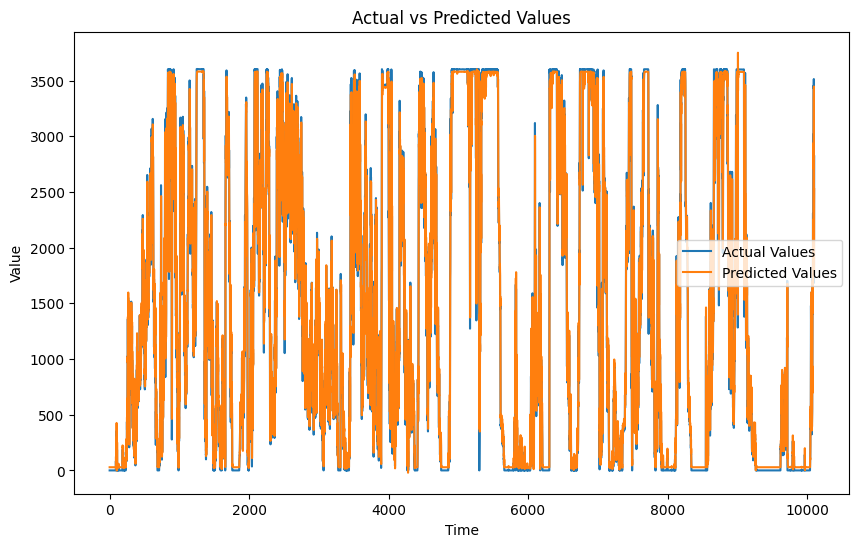

In [11]:
# Step 6: Evaluate and visualize
# Make predictions
y_pred = model.predict(X_test)

# Inverse transform to original scale
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_actual = scaler.inverse_transform(y_pred)

# Evaluate performance
rmse = math.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2 = r2_score(y_test_actual, y_pred_actual)

print("RMSE:", rmse)
print("R2 Score:", r2)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(y_test_actual, label='Actual Values')
plt.plot(y_pred_actual, label='Predicted Values')
plt.title('Actual vs Predicted Values')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()